# Message Passing Neural Networks on QM9

This notebook builds a **graph-level property predictor on QM9** using **PyTorch Geometric (PyG)**, following the general Message Passing Neural Network (MPNN) framework of [Gilmer et al., 2017 — "Neural Message Passing for Quantum Chemistry"](https://arxiv.org/abs/1704.01212).

**Where this sits in the curriculum.** In the previous notebook (`gcn-from-scratch.ipynb`) we implemented a 2-layer GCN using only plain PyTorch tensor ops, on Zachary's Karate Club, for node classification. That exercise was about understanding the mechanics of neighbor aggregation and message passing *by hand* — writing out the normalized adjacency matrix, the propagation rule, everything ourselves.

Here the goal is different. We already understand the mechanics, so this time **PyG is expected and encouraged**: we use its `Data`/`Batch` objects, its `DataLoader` for graph batching, and its `MessagePassing` base class for the propagate/message/aggregate/update scaffolding. What we still write ourselves is the actual *content* of the message function, the update function, and the overall model — the parts that define "MPNN" as opposed to some other architecture. This mirrors how you'd work in practice: nobody reimplements scatter-add by hand in a real project, but you do need to understand precisely what a `MessagePassing` subclass is doing under the hood, which the previous notebook bought us.

**Task.** Graph-level regression: given a molecule's connectivity graph (atoms as nodes, bonds as edges), predict a single scalar quantum-chemical property, using [QM9](https://www.nature.com/articles/sdata201422) (~130k small organic molecules with DFT-computed properties).

**Why this design matters for what comes next.** The stage after this one is *equivariant* networks (operating directly on 3D atomic coordinates with rotation/translation equivariance), followed by generative models for materials. So a deliberate choice here: **this model uses only the molecular graph (atoms + bond connectivity) and ignores the 3D atomic coordinates (`pos`) that QM9 also provides.** That's not an oversight — plain message passing over a graph has no built-in notion of 3D geometry or rotational equivariance, so mixing in raw coordinates here would be either useless or actively wrong (predictions would depend on how the molecule happens to be rotated in the input file, which is physically meaningless). Handling `pos` correctly *is* the whole point of the equivariant-networks stage. Keeping this stage graph-only makes the contrast sharp later: same dataset, same targets, but a model that structurally cannot be fooled by rotation.

**Extensibility.** The code is organized so a `MessagePassing` layer is a self-contained, swappable unit:
- `MPNNLayer` — the message/aggregate/update logic. This is the piece we'll later replace with an equivariant layer.
- `MPNNModel` — embedding → stacked message-passing rounds → graph readout → MLP head. This wrapper shouldn't need to change when the layer changes.
- Training loop, data splitting, and normalization — generic to any graph-level regression model, independent of the layer's internals.

That separation is the actual point of "stage 1 complete": not just a working model, but a *harness* (data pipeline, training loop, evaluation) that the next several notebooks can reuse by swapping out one class.

In [1]:
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_add_pool

torch.manual_seed(0)

print("torch:", torch.__version__)
import torch_geometric
print("torch_geometric:", torch_geometric.__version__)
print("cuda available:", torch.cuda.is_available())

/home/daniyusra/projects/manantara-playground/learning-habits/.venv/lib/python3.11/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


/home/daniyusra/projects/manantara-playground/learning-habits/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/daniyusra/projects/manantara-playground/learning-habits/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


torch: 2.14.0+cu130
torch_geometric: 2.8.0.post1
cuda available: False


## 1. Load QM9 and look at what a single graph contains

PyG's `QM9` dataset class handles downloading, parsing, and caching automatically — it hands us back a list-like object of `Data` instances, one per molecule. This is a good moment to actually inspect one, since every field here maps directly onto how we'll build the model.

For each molecule, PyG gives us:
- `x` — node (atom) feature matrix, shape `(num_atoms, 11)`. This is a hand-crafted one-hot-ish atom feature vector from the original MPNN paper (atom type, atomic number, aromaticity, hybridization, etc.) — not just element identity.
- `edge_index` — shape `(2, num_edges)`, the COO-format list of directed bond endpoints (each undirected bond appears as two directed edges, `i→j` and `j→i`, which is what `MessagePassing` expects).
- `edge_attr` — shape `(num_edges, 4)`, a one-hot bond type: single / double / triple / aromatic.
- `pos` — shape `(num_atoms, 3)`, the 3D atomic coordinates from the DFT-optimized geometry. **We will not use this field** — see the intro above for why.
- `z` — atomic numbers, shape `(num_atoms,)`. Redundant with part of `x`; also unused here.
- `y` — shape `(1, 19)`, the 19 regression targets PyG provides for this molecule (dipole moment, polarizability, HOMO/LUMO energies, heat capacity, etc.), already unit-converted to consistent physical units (eV for energies, Debye for dipole, etc.) during preprocessing.

In [2]:
dataset = QM9(root="data/qm9")

print(f"num graphs: {len(dataset)}")
print(f"node feature dim: {dataset.num_node_features}")
print(f"edge feature dim: {dataset.num_edge_features}")
print(f"num targets per graph: {dataset.y.shape[-1] if hasattr(dataset, 'y') else dataset[0].y.shape[-1]}")

example = dataset[0]
print()
print("example molecule:", example)

num graphs: 130831
node feature dim: 11
edge feature dim: 4
num targets per graph: 19

example molecule: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])


## 2. Picking a target: dipole moment (μ), not an energy

QM9 ships 19 targets. The two most commonly suggested starting points are an internal-energy-like quantity (e.g. `U0`, internal energy at 0K) and the dipole moment `μ`. It's worth explaining why **dipole moment is the better pedagogical choice here**, even though energies are the more "famous" QM9 benchmark.

**The problem with energetic targets.** `U0`, `U`, `H`, `G` are all *extensive* quantities dominated by simple atom counting: a molecule's total electronic energy is overwhelmingly just the sum of its atoms' reference energies, with the actual chemistry (bonding, structure) contributing a comparatively tiny correction on top. A model — even a bad one — that merely learns "count carbons, count hydrogens, count oxygens, add up reference constants" gets deceptively good-looking MAE on raw `U0` without having learned anything about graph structure. (This is precisely why serious QM9 energy benchmarks report MAE on the *atomization energy*, i.e. `U0` minus a fixed per-atom reference energy, not on raw `U0` — that subtraction is exactly what removes the trivial atom-counting signal.) Using raw `U0` here would risk building a pipeline that "works" for the wrong reason, which defeats the point of this exercise.

**Why dipole moment avoids this.** `μ` depends on the spatial distribution of partial charges — i.e. on *which* atoms are bonded to *which*, on electronegativity differences across bonds, and on the topology of the molecule (a symmetric molecule can have zero dipole even with polar bonds, e.g. CO2). There's no "just count the atoms" shortcut: two molecules with the same formula but different connectivity have different dipole moments. That makes it an honest test of whether the message-passing layer is actually learning something about graph structure. It's also literally one of the targets Gilmer et al. benchmark in the paper this notebook follows, with a well-known "chemical accuracy" threshold (**0.1 Debye**) we can use to sanity-check our result at the end.

We'll standardize the target (zero mean, unit variance) purely for training stability — the raw scale (~0 to ~10 Debye, roughly) is fine for a neural net, but centering and scaling makes the loss landscape better conditioned and the initial predictions less wildly wrong. We always compute the mean/std from the **training split only**, to avoid leaking test-set statistics into how the model is trained.

dipole moment (mu): min=0.000, max=29.556, mean=2.673, std=1.503


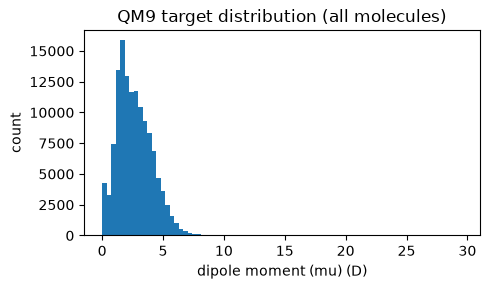

In [3]:
TARGET_IDX = 0  # mu: dipole moment, in Debye
TARGET_NAME = "dipole moment (mu)"
TARGET_UNIT = "D"

all_targets = dataset.y[:, TARGET_IDX]
print(f"{TARGET_NAME}: min={all_targets.min():.3f}, max={all_targets.max():.3f}, "
      f"mean={all_targets.mean():.3f}, std={all_targets.std():.3f}")

plt.figure(figsize=(5, 3))
plt.hist(all_targets.numpy(), bins=80)
plt.xlabel(f"{TARGET_NAME} ({TARGET_UNIT})")
plt.ylabel("count")
plt.title("QM9 target distribution (all molecules)")
plt.tight_layout()
plt.show()

## 3. Train / validation / test split, and target normalization

Standard 80/10/10 random split. We fix the RNG seed so the split is reproducible across reruns (important once we start comparing this model against equivariant variants later — they need to be evaluated on the *same* held-out molecules).

Normalization: compute `mean`/`std` of the target **on the training split only**, then standardize all three splits with those same statistics. The model trains against the standardized target (better-conditioned loss); we un-standardize predictions before computing MAE, so the reported MAE is in real Debye units, directly comparable to published baselines.

In [4]:
SPLIT_SEED = 0

n = len(dataset)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

perm = torch.randperm(n, generator=torch.Generator().manual_seed(SPLIT_SEED))
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

print(f"train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")

train_targets = dataset.y[train_idx, TARGET_IDX]
target_mean = train_targets.mean()
target_std = train_targets.std()
print(f"train-set target mean={target_mean:.4f}, std={target_std:.4f}")


def standardize(y):
    return (y - target_mean) / target_std


def unstandardize(y_std):
    return y_std * target_std + target_mean

train: 104664, val: 13083, test: 13084
train-set target mean=2.6715, std=1.5049


## 4. Batching graphs of different sizes

Molecules have different numbers of atoms, so we can't just stack `x` tensors like we would for fixed-size images. PyG's `DataLoader` handles this by taking a batch of separate graphs and merging them into **one big disconnected graph**: node feature matrices are concatenated along dim 0, `edge_index` values are offset per-graph so edges still point to the right (now-relabeled) nodes, and a `batch` vector of shape `(total_num_nodes,)` records which original graph each node came from (`batch[i] == g` means node `i` belongs to graph `g`).

This matters directly for the model: since messages only ever flow along `edge_index`, and there are no edges *between* the different molecules in a batch, message passing on the merged graph is mathematically identical to running it on each molecule separately — batching is "free" in the sense that it doesn't change what the model computes, only how efficiently it's computed. The `batch` vector is what lets us later pool node features back into one vector *per molecule* (rather than one vector for the whole disconnected mega-graph) at readout time.

In [5]:
BATCH_SIZE = 128

train_loader = DataLoader(dataset[train_idx], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset[val_idx], batch_size=256, shuffle=False)
test_loader = DataLoader(dataset[test_idx], batch_size=256, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("batch vector (first 20 entries):", batch.batch[:20])
print("num graphs in this batch:", batch.num_graphs)

DataBatch(x=[2335, 11], edge_index=[2, 4866], edge_attr=[4866, 4], y=[128, 19], pos=[2335, 3], idx=[128], name=[128], z=[2335], batch=[2335], ptr=[129])
batch vector (first 20 entries): tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])
num graphs in this batch: 128


## 5. The MPNN framework, and how it maps onto `MessagePassing`

Gilmer et al. describe message passing as two phases repeated for $T$ steps, followed by a readout:

$$m_v^{t+1} = \sum_{w \in N(v)} M_t\left(h_v^t,\, h_w^t,\, e_{vw}\right) \qquad\qquad h_v^{t+1} = U_t\left(h_v^t,\, m_v^{t+1}\right)$$

$$\hat{y} = R\left(\{h_v^T \mid v \in G\}\right)$$

- $M_t$ — the **message function**: combines a node's own hidden state, a neighbor's hidden state, and the edge features between them, into a message. Applied identically to every edge (weight sharing across edges is what makes this a *graph* operation rather than a per-node MLP).
- $\sum_{w \in N(v)}$ — **permutation-invariant aggregation** over a node's neighbors. Sum (rather than, say, concatenation) is what makes the layer work on nodes with any number of neighbors, and guarantees the result doesn't depend on the arbitrary order neighbors happen to be listed in.
- $U_t$ — the **update function**: combines a node's previous state with the aggregated incoming message to produce its new state.
- $T$ — the number of message-passing rounds. Each round lets information travel one more hop, so after $T$ rounds a node's representation is influenced by everything within $T$ bonds of it.
- $R$ — the **readout**: a permutation-invariant function pooling all final node states into one fixed-size graph-level vector, since a molecule's dipole moment is a property of the whole graph, not any one atom.

PyG's `MessagePassing` base class is built around exactly this decomposition: you subclass it and implement `message(...)` (that's $M_t$) and optionally `update(...)` (that's $U_t$); `aggr='add'` tells it to use sum for the $\sum_{w \in N(v)}$ step; calling `self.propagate(edge_index, ...)` runs the whole per-edge message → scatter-sum → update pipeline for you. This is the scaffolding we hand-built from raw tensor ops last time — now we get to use it directly, while still writing $M_t$ and $U_t$ ourselves.

**Our specific choices:**
- **Message function** $M_t$: a 2-layer MLP over the concatenation `[h_v, h_w, e_vw]`. This is the most direct, literal implementation of the general equation above — it can in principle learn any function of the three inputs. (The original paper's QM9 experiments used a fancier variant — an "edge network" that maps `e_vw` to a full weight matrix and multiplies it with `h_w` — which is more expressive but adds real complexity for a modest gain; a good candidate to try as a follow-up exercise.)
- **Update function** $U_t$: a `GRUCell`. Instead of a plain MLP, a gated recurrent update lets the node decide, per-round, how much of the incoming message to actually incorporate versus keep its existing state — which matters because we're about to run $T=3$ rounds and want the same update rule reused each round without state blowing up or collapsing. This also mirrors the paper directly (they use a GRU too).
- **Weight sharing across rounds**: we instantiate *one* `MPNNLayer` and call it $T$ times, rather than stacking $T$ independently-parameterized layers. This treats the $T$ rounds of message passing as a recurrent computation over the graph (same transition function applied repeatedly) — fewer parameters, and a cleaner match to the $M_t = M$, $U_t = U$ (time-independent) case Gilmer et al. also discuss.
- **Aggregation**: sum (`aggr='add'`), matching the general formula exactly.

In [6]:
class MPNNLayer(MessagePassing):
    """One round of message passing: message -> sum-aggregate -> GRU update.

    This is the single class we'll swap out for an equivariant layer later;
    everything else in the pipeline (model wrapper, training loop, data)
    should be able to stay the same.
    """

    def __init__(self, hidden_dim: int, edge_dim: int):
        super().__init__(aggr="add")  # sum aggregation, per the MPNN equations
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_gru = nn.GRUCell(hidden_dim, hidden_dim)

    def forward(self, h, edge_index, edge_attr):
        # propagate() calls message() once per edge, sums the results per
        # target node (because aggr="add"), and hands us the aggregated
        # per-node message back here.
        aggregated_message = self.propagate(edge_index, h=h, edge_attr=edge_attr)
        return self.update_gru(aggregated_message, h)

    def message(self, h_i, h_j, edge_attr):
        # h_i: hidden state of the message *receiver* (target node)
        # h_j: hidden state of the message *sender* (neighbor / source node)
        # PyG resolves the "_i"/"_j" suffixes on any `forward` kwarg automatically.
        return self.message_mlp(torch.cat([h_i, h_j, edge_attr], dim=-1))

## 6. The full model: embed -> message pass -> pool -> predict

Three pieces, each doing one job:

1. **Node embedding** (`nn.Linear`): the raw 11-dim atom feature vector isn't in the units our hidden layers work in, so we project it into a `hidden_dim`-dimensional space first. This is the *only* place the raw atom features are read directly — after this, every node's identity is only visible through its learned hidden state.
2. **`T` rounds of `MPNNLayer`** (weight-shared, as discussed above): after $T=3$ rounds, each node's hidden state has aggregated information from every node within 3 bonds.
3. **Readout**: `global_add_pool` sums all node hidden states belonging to the same molecule (using the `batch` vector from the DataLoader) into one graph-level vector, then a small MLP maps that to a single scalar. Sum pooling (rather than mean) is the simpler, more common default in this literature and is what the general MPNN readout equation naturally suggests — a molecule's dipole is a function of *all* its atoms' contributions, not their average. (`Set2Set`, the pooling PyG also provides and which the original paper uses, is a fancier permutation-invariant alternative that runs its own small LSTM-attention loop over the node set — a reasonable upgrade to try, but not necessary to get a working, well-understood pipeline here.)

Notice `MPNNModel.forward` never touches `edge_index`/`edge_attr` directly except to hand them to the layer — all the graph-structure-specific logic is fully contained in `MPNNLayer`. That's the seam we'll cut along when we build the equivariant version.

In [7]:
class MPNNModel(nn.Module):
    def __init__(self, node_in_dim: int, edge_in_dim: int, hidden_dim: int = 64, num_steps: int = 3):
        super().__init__()
        self.embed = nn.Linear(node_in_dim, hidden_dim)
        self.mp_layer = MPNNLayer(hidden_dim, edge_in_dim)
        self.num_steps = num_steps
        self.readout_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data):
        h = self.embed(data.x)
        for _ in range(self.num_steps):
            h = self.mp_layer(h, data.edge_index, data.edge_attr)
        graph_repr = global_add_pool(h, data.batch)
        return self.readout_mlp(graph_repr).squeeze(-1)


model = MPNNModel(
    node_in_dim=dataset.num_node_features,
    edge_in_dim=dataset.num_edge_features,
    hidden_dim=64,
    num_steps=3,
)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

MPNNModel(
  (embed): Linear(in_features=11, out_features=64, bias=True)
  (mp_layer): MPNNLayer()
  (readout_mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
trainable parameters: 42625


## 7. Training loop

Kept deliberately generic — nothing here knows or cares that the layer inside `model` is an `MPNNLayer` specifically. Swapping in an equivariant model later should mean changing the model-construction cell, not this one.

Two functions:
- `run_epoch(loader, train=True)` — one pass over a loader. Trains on the **standardized** target (MSE loss), but always reports **MAE in real units** (Debye) by un-standardizing predictions first, since that's the metric we actually care about and want comparable to published numbers.
- We track the best validation MAE across epochs and keep that checkpoint's weights, then report test performance using the best-on-validation model rather than whatever the last epoch happened to produce — standard practice to avoid reporting a lucky (or unlucky) final epoch.

In [8]:
def run_epoch(model, loader, optimizer=None):
    """One pass over `loader`. Trains if `optimizer` is given, else evaluates.

    Returns (mean squared error on the standardized target, mean absolute
    error on the original-scale target).
    """
    train = optimizer is not None
    model.train(train)

    total_mse, total_mae, n_graphs = 0.0, 0.0, 0
    with torch.set_grad_enabled(train):
        for data in loader:
            target_std = standardize(data.y[:, TARGET_IDX])
            pred_std = model(data)

            loss = F.mse_loss(pred_std, target_std)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            pred = unstandardize(pred_std.detach())
            mae = (pred - data.y[:, TARGET_IDX]).abs().sum().item()

            total_mse += loss.item() * data.num_graphs
            total_mae += mae
            n_graphs += data.num_graphs

    return total_mse / n_graphs, total_mae / n_graphs

## 8. Run training

We use `ReduceLROnPlateau` to halve the learning rate if validation loss stalls — with a recurrent-style GRU update over several message-passing rounds, a fixed learning rate for the whole run tends to plateau earlier than necessary. Everything is logged into `history` so we can plot the curves afterward.

This runs on CPU (no usable CUDA GPU in this environment) — QM9's graphs are tiny (a handful to a few dozen atoms each) so a modest hidden size keeps this tractable, but expect real wall-clock time (tens of minutes) for the full 130k-molecule dataset over many epochs.

In [9]:
NUM_EPOCHS = 40

torch.manual_seed(0)
model = MPNNModel(
    node_in_dim=dataset.num_node_features,
    edge_in_dim=dataset.num_edge_features,
    hidden_dim=64,
    num_steps=3,
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history = {"train_mse": [], "val_mse": [], "train_mae": [], "val_mae": []}
best_val_mae = float("inf")
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_mse, train_mae = run_epoch(model, train_loader, optimizer)
    val_mse, val_mae = run_epoch(model, val_loader)
    scheduler.step(val_mse)

    history["train_mse"].append(train_mse)
    history["val_mse"].append(val_mse)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    lr = optimizer.param_groups[0]["lr"]
    print(f"epoch {epoch:2d}/{NUM_EPOCHS} | train MSE(std) {train_mse:.4f} | "
          f"val MAE {val_mae:.4f} {TARGET_UNIT} | lr {lr:.1e} | {time.time() - t0:.1f}s")

print(f"\nbest validation MAE: {best_val_mae:.4f} {TARGET_UNIT}")
model.load_state_dict(best_state)

epoch  1/40 | train MSE(std) 0.6260 | val MAE 0.7569 D | lr 1.0e-03 | 51.4s


epoch  2/40 | train MSE(std) 0.4472 | val MAE 0.7587 D | lr 1.0e-03 | 39.7s


epoch  3/40 | train MSE(std) 0.3773 | val MAE 0.7111 D | lr 1.0e-03 | 36.8s


epoch  4/40 | train MSE(std) 0.3444 | val MAE 0.6491 D | lr 1.0e-03 | 41.8s


epoch  5/40 | train MSE(std) 0.3241 | val MAE 0.6225 D | lr 1.0e-03 | 35.9s


...

epoch 37/40 | train MSE(std) 0.1639 | val MAE 0.4775 D | lr 5.0e-04 | 35.1s


epoch 38/40 | train MSE(std) 0.1627 | val MAE 0.4706 D | lr 5.0e-04 | 34.7s


epoch 39/40 | train MSE(std) 0.1610 | val MAE 0.4726 D | lr 5.0e-04 | 34.6s


epoch 40/40 | train MSE(std) 0.1594 | val MAE 0.4735 D | lr 5.0e-04 | 35.1s

best validation MAE: 0.4706 D


<All keys matched successfully>

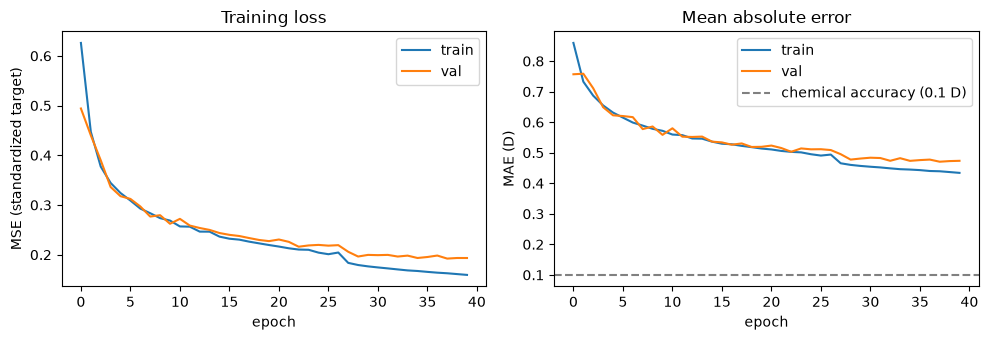

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(history["train_mse"], label="train")
axes[0].plot(history["val_mse"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE (standardized target)")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_mae"], label="train")
axes[1].plot(history["val_mae"], label="val")
axes[1].axhline(0.1, color="gray", linestyle="--", label="chemical accuracy (0.1 D)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"MAE ({TARGET_UNIT})")
axes[1].set_title("Mean absolute error")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Final evaluation on the held-out test set

This is the number that matters: MAE on molecules the model has never seen in training *or* used for model selection (that's what the val set was for). For context, on QM9 dipole moment: "chemical accuracy" is conventionally **0.1 D**; simple baselines (e.g. models that don't do full message passing) tend to land somewhere in the 0.3–1.0 D range, and the enn-s2s model in Gilmer et al. (a much larger, more carefully tuned MPNN with the edge-network message function and Set2Set readout, trained far longer) gets down to **~0.030 D**. We're not trying to match that — this is a smaller model, simpler message function, sum pooling instead of Set2Set, and a modest training budget — but landing meaningfully below the "just predict the mean" baseline and in the same order of magnitude as published simple baselines is the actual success criterion here.

In [11]:
test_mse, test_mae = run_epoch(model, test_loader)

# naive baseline for context: always predict the training-set mean
mean_baseline_mae = (dataset.y[test_idx, TARGET_IDX] - target_mean).abs().mean().item()

print(f"test MAE ({TARGET_NAME}): {test_mae:.4f} {TARGET_UNIT}")
print(f"naive mean-prediction baseline MAE: {mean_baseline_mae:.4f} {TARGET_UNIT}")
print(f"chemical accuracy threshold: 0.100 {TARGET_UNIT}")

test MAE (dipole moment (mu)): 0.4649 D
naive mean-prediction baseline MAE: 1.1632 D
chemical accuracy threshold: 0.100 D


## Recap, and what's swappable going forward

**What we built:** a full MPNN graph-level regression pipeline on QM9 — data loading and batching (PyG), a hand-written `MessagePassing` layer implementing the Gilmer et al. message/aggregate/update decomposition (concat-MLP message, sum aggregation, GRU update, weight-shared across rounds), a thin model wrapper doing embed → message-pass → sum-pool → MLP, and a generic training loop with proper train/val/test splitting, target standardization fit only on train, learning-rate scheduling, and best-checkpoint selection by validation MAE.

**What's designed to change next (equivariant networks):**
- Swap `MPNNLayer` for a layer that consumes `data.pos` and is equivariant to rotations/translations of those coordinates (e.g. an E(n)-equivariant layer that passes both scalar hidden states *and* the geometric position update between nodes). `MPNNModel`'s `forward` will need to also thread `pos` through, but the embed → message-pass loop → readout *shape* stays the same.
- The training loop, splitting, and normalization code shouldn't need to change at all — that genericity was the point of keeping them separate from the layer's internals.
- A natural sanity check once that's built: verify equivariance directly (rotate `pos` by a random rotation matrix, confirm the prediction for an invariant target like dipole *magnitude* is unchanged — something this plain-graph model has no way to guarantee, since it never sees `pos` in the first place).
- Worth trying as a smaller follow-up even before equivariant nets: swap sum-pooling for `Set2Set`, or swap the concat-MLP message for the paper's edge-network variant, and see how much of the gap to the enn-s2s baseline either change closes on its own.